## Modeling Class Probabilities via Logistic Regression

Despite its name, **logistic regression** is a widely used linear model for classification, not regression. It serves as a more robust alternative to the perceptron, particularly because the perceptron fails to converge if the classes are not perfectly linearly separable.

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch03/figures/03_03.png" width="600">
</p>

### 1. Logistic regression and conditional probabilities

To understand logistic regression as a probabilistic model, we first define the **odds** in favor of a positive event (the event we want to predict):
$$\text{Odds} = \frac{p}{1-p}$$
*(Where $p$ is the conditional probability that an example belongs to class 1 given its features, $p := p(y=1|\mathbf{x})$).*

The **logit function** is the natural logarithm of these odds (log-odds). It takes input values in the range $[0, 1]$ and transforms them to the entire real-number range:
$$\text{logit}(p) = \log\left(\frac{p}{1 - p}\right)$$

In logistic regression, we assume a linear relationship between the log-odds and the weighted inputs (net input, $z$):
$$\text{logit}(p) = \mathbf{w}^T\mathbf{x} + b$$

To predict the actual probability $p$ given the features, we need the inverse of the logit function. This inverse is called the **logistic sigmoid function** (or simply the sigmoid function):
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
*(Where $z$ is the net input: $z = \mathbf{w}^T\mathbf{x} + b$)*

**Key properties of the sigmoid function:**
* Maps any real-numbered net input to a probability range of $[0, 1]$.
* Creates a characteristic S-shaped curve.
* Approaches $1$ as $z \to \infty$ and approaches $0$ as $z \to -\infty$.
* The intercept is at $\sigma(0) = 0.5$.

### Plot the Sigmoid Function

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4291/1037530521.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma (z)$')


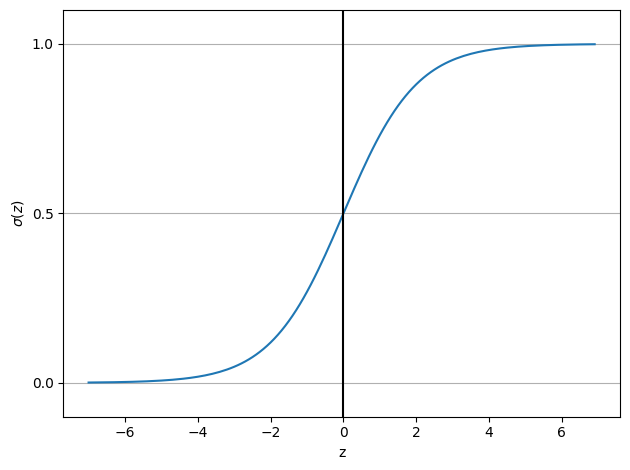

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
sigma_z = sigmoid(z)

plt.plot(z, sigma_z)
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel('$\sigma (z)$')

plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

## 2. Learning Model Weights via the Logistic Loss Function

To fit the parameters (weights $w$ and bias $b$) of a logistic regression model, we need an objective function to optimize. Unlike the Mean Squared Error (MSE) used in models like Adaline, logistic regression uses a loss function derived from maximum likelihood estimation.

### 2.1. The Likelihood Function
Assuming that the individual examples in our dataset are independent, we want to maximize the **likelihood** ($\mathcal{L}$) of the training labels given the features.

For a binary classification problem (classes $0$ and $1$), we treat the label as a Bernoulli variable. The probability mass function for a single example is:
$$p(y^{(i)} | \mathbf{x}^{(i)}) = \left(\sigma(z^{(i)})\right)^{y^{(i)}} \left(1 - \sigma(z^{(i)})\right)^{1 - y^{(i)}}$$

Using the multiplication rule for independent events, the likelihood for the entire dataset is the product of these individual probabilities:
$$\mathcal{L}(\mathbf{w}, b | \mathbf{x}) = \prod_{i=1}^n \left(\sigma(z^{(i)})\right)^{y^{(i)}} \left(1 - \sigma(z^{(i)})\right)^{1 - y^{(i)}}$$

### 2.2. The Log-Likelihood Function
In practice, it is mathematically easier to maximize the natural logarithm of the likelihood function, known as the **log-likelihood**.
* **Prevents numerical underflow:** Very small likelihoods can cause issues in computation.
* **Simplifies derivation:** Converts products into sums, making it easier to calculate derivatives.

$$l(\mathbf{w}, b | \mathbf{x}) = \sum_{i=1}^n \left[ y^{(i)} \log(\sigma(z^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right]$$

### 2.3. The Logistic Loss Function
While we could use gradient ascent to *maximize* the log-likelihood, it is standard practice to rewrite this as a loss function ($L$) to *minimize* using gradient descent. We do this by simply multiplying the log-likelihood by $-1$:

$$L(\mathbf{w}, b) = \sum_{i=1}^n \left[ -y^{(i)} \log(\sigma(z^{(i)})) - (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right]$$

### 2.4. Loss for a Single Training Example
To better understand this function, let's look at the loss calculated for just one training example:
$$L(\sigma(z), y; \mathbf{w}, b) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z))$$

This equation simplifies cleanly depending on the true class label ($y$):
* **If $y = 1$:** The second term becomes zero, leaving $L = -\log(\sigma(z))$
* **If $y = 0$:** The first term becomes zero, leaving $L = -\log(1 - \sigma(z))$

**Interpretation:** The loss approaches $0$ if the model correctly predicts the class probability. However, if the prediction is completely wrong, the loss goes toward infinity. This ensures wrong predictions are heavily penalized.

### Plot the loss function used in logistic regression

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4291/844776843.py:19: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma(z)$')


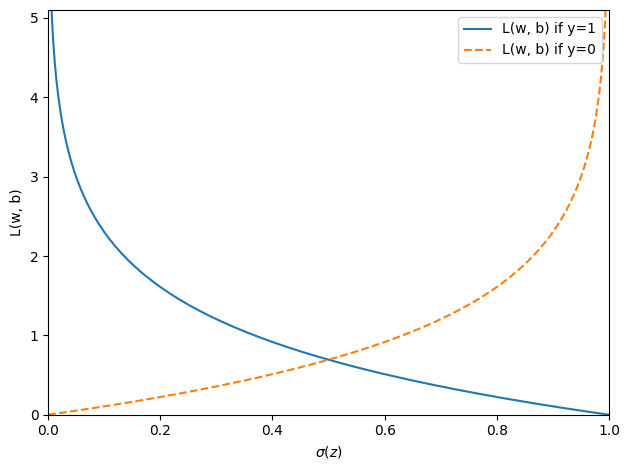

In [ ]:
def loss_1(z):
    return - np.log(sigmoid(z))


def loss_0(z):
    return - np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)

c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label='L(w, b) if y=1')

c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle='--', label='L(w, b) if y=0')

plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel('$\sigma(z)$')
plt.ylabel('L(w, b)')
plt.legend(loc='best')
plt.tight_layout()
#plt.savefig('figures/03_04.png', dpi=300)
plt.show()